In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="IXzKrxKhYSUYRyd5OJaN")
project = rf.workspace("norah-alshowair").project("using-phone-while-driving-qcvye-tjjun")
version = project.version(2)
dataset = version.download("yolov8")




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Using-phone-while-driving-2 in yolov8:: 100%|██████████| 8569/8569 [00:01<00:00, 7050.20it/s]


In [ ]:
# 1. Install Ultralytics library
!pip install ultralytics -q

# 2. Import libraries and initialize training
from ultralytics import YOLO
from google.colab import files

# Load pre-trained nano model for faster convergence
model = YOLO('yolov8n.pt')

# Train with optimized parameters for faster training time
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=15,          # Reduced epochs to speed up training
    batch=64,           # Increased batch size to maximize GPU throughput
    imgsz=480,          # Reduced image size for significantly faster processing
    workers=2,
    patience=5,
    name='phone_combined_fast'
)

# 3. Model Validation & Performance Metrics
print("\n--- Final Model Evaluation Metrics ---")
metrics = model.val()
print(f"🎯 Overall Accuracy (mAP@50): {metrics.box.map50 * 100:.2f}%")
print(f"🔍 Precision: {metrics.box.mp * 100:.2f}%")
print(f"📡 Recall: {metrics.box.mr * 100:.2f}%")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 7.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Using-phone-while-driving-2/d

Please select an image to upload...


Saving img_64937.jpg to img_64937 (1).jpg

image 1/1 /content/img_64937 (1).jpg: 384x480 1 phone, 1 wheel, 30.3ms
Speed: 6.5ms preprocess, 30.3ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 480)


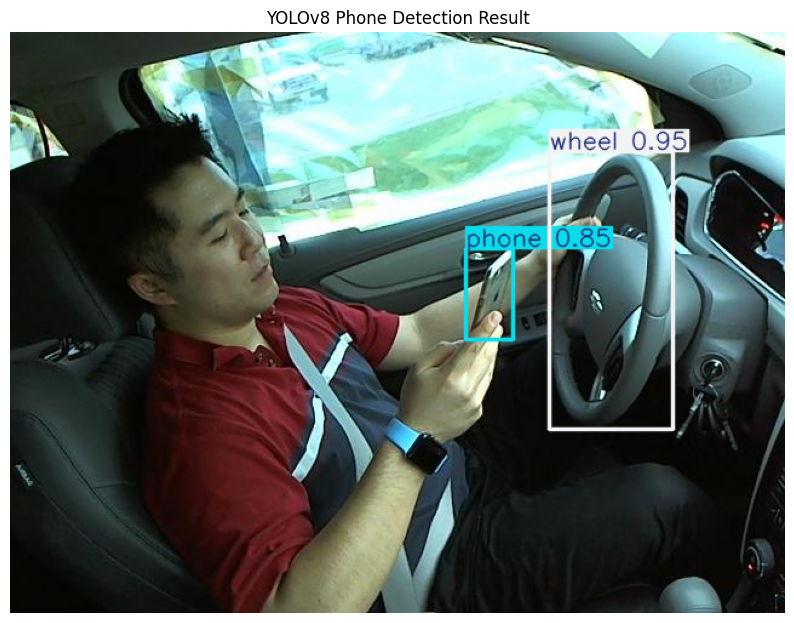

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from ultralytics import YOLO

# 1. Load the best trained model weights
trained_model = YOLO("runs/detect/phone_combined_fast/weights/best.pt")

# 2. Upload an image from your local machine
print("Please select an image to upload...")
uploaded = files.upload()
image_name = list(uploaded.keys())[0]

# 3. Run inference
results = trained_model.predict(source=image_name, conf=0.25, save=False)

# 4. Plot detections and display the result
res_plotted = results[0].plot()
res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(res_rgb)
plt.axis("off")
plt.title("YOLOv8 Phone Detection Result")
plt.show()

In [14]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="IXzKrxKhYSUYRyd5OJaN")
project = rf.workspace("norah-alshowair").project("seatbelt-detection-w8dln-9fhri")
version = project.version(2)
dataset = version.download("yolov8")



loading Roboflow workspace...
loading Roboflow project...


In [18]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="IXzKrxKhYSUYRyd5OJaN")
project = rf.workspace("norah-alshowair").project("seatbelt-detection-w8dln-9fhri")
version = project.version(1)
dataset = version.download("yolov8-obb")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Seatbelt-Detection-1 in yolov8-obb:: 100%|██████████| 2101/2101 [00:00<00:00, 3969.50it/s]


In [19]:

!pip install ultralytics roboflow -q

import torch
from roboflow import Roboflow
from ultralytics import YOLO


rf = Roboflow(api_key="IXzKrxKhYSUYRyd5OJaN")
project = rf.workspace("norah-alshowair").project("seatbelt-detection-di1xz-u2rhe")
version = project.version(1)
dataset = version.download("yolov8-obb")


torch.cuda.empty_cache()
model = YOLO("yolov8n-obb.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=7,
    name="seatbelt_obb_v1_model"
)

metrics = model.val()
print("\n" + "="*40)
print(f"🎯 mAP@50:    {metrics.box.map50 * 100:.2f}%")
print(f"🎯 mAP@50-95: {metrics.box.map * 100:.2f}%")
print(f"🔍 Precision: {metrics.box.mp * 100:.2f}%")
print(f"📡 Recall:    {metrics.box.mr * 100:.2f}%")
print("="*40)

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8-obb in progress : 22.0%
Version export complete for yolov8-obb format



Extracting Dataset Version Zip to seatbelt-detection-1 in yolov8-obb:: 100%|██████████| 1005/1005 [00:00<00:00, 6254.73it/s]


New https://pypi.org/project/ultralytics/8.4.129 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/seatbelt-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0,

Please upload an image to test seatbelt detection:


Saving img_11658 (1).jpg to img_11658 (1).jpg

image 1/1 /content/img_11658 (1).jpg: 480x640 1 Seatbelt, 6.4ms
Speed: 1.7ms preprocess, 6.4ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)


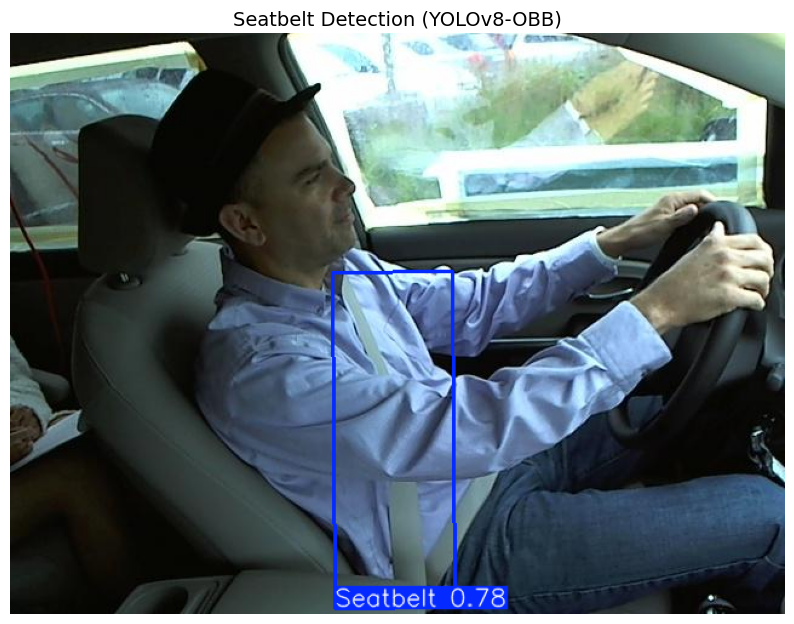

✅ Seatbelt fastened! Confidence: 77.79%


In [20]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from ultralytics import YOLO

# 1. Load the trained YOLOv8-OBB model
model_path = "/content/runs/obb/seatbelt_obb_v1_model/weights/best.pt"
model = YOLO(model_path)

# 2. Upload the test image to Colab
print("Please upload an image to test seatbelt detection:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# 3. Run inference with OBB support
results = model.predict(source=image_path, conf=0.35, imgsz=640)
annotated_frame = results[0].plot()

# 4. Display the detected image
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Seatbelt Detection (YOLOv8-OBB)", fontsize=14)
plt.show()

# 5. Check and print detection status
if results[0].obb is not None and len(results[0].obb) > 0:
  conf_score = float(results[0].obb.conf[0]) * 100
  print(f"✅ Seatbelt fastened! Confidence: {conf_score:.2f}%")
else:
  print("⚠️ Violation: Seatbelt NOT detected!")

In [21]:
from google.colab import files


files.download('/content/runs/obb/seatbelt_obb_v1_model/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>